In [ ]:
!unzip -q archive.zip
!ls


archive.zip  sample_data  test	train


In [ ]:
!ls /content/train

angry  disgust	fear  happy  neutral  sad  surprise


# CNN

In [ ]:
# How to do augmentations
# How to remove the "disgust" class
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

DATA_ROOT = "/content"
BATCH_SIZE = 128
IMAGE_W = 224
IMAGE_H = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((52, 52)),
    transforms.RandomResizedCrop(48, scale=(0.9, 1.1)),
    transforms.RandomApply([
        transforms.RandomAffine(
            degrees=0,
            translate=(0.1, 0.1)
        )
    ], p=0.5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.RandomRotation(10)
    ], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.RandomErasing(p=0.5)
])

test_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])



train_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, "train"), transform=train_transform
)
test_dataset  = datasets.ImageFolder(
    os.path.join(DATA_ROOT, "test"),  transform=test_transform
)

print("classes before drop:", train_dataset.classes)

def drop_class(dataset, class_name="disgust"):
    if class_name not in dataset.class_to_idx:
        print(f"{class_name} not found in dataset. No class removed.")
        return dataset

    drop_idx = dataset.class_to_idx[class_name]
    new_samples = []
    new_targets = []

    for path, label in dataset.samples:
        if label == drop_idx:
            continue
        new_label = label - 1 if label > drop_idx else label
        new_samples.append((path, new_label))
        new_targets.append(new_label)

    dataset.samples = new_samples
    dataset.imgs    = new_samples
    dataset.targets = new_targets

    new_classes = [c for c in dataset.classes if c != class_name]
    dataset.classes = new_classes
    dataset.class_to_idx = {c: i for i, c in enumerate(new_classes)}

    print(f"Removed class '{class_name}'. New dataset size: {len(dataset)}")
    print("Updated class_to_idx:", dataset.class_to_idx)
    return dataset

train_dataset = drop_class(train_dataset, "disgust")
test_dataset  = drop_class(test_dataset,  "disgust")

NUM_CLASSES = len(train_dataset.classes)
print("NUM_CLASSES:", NUM_CLASSES)

from torch.utils.data import random_split

full_train_dataset = train_dataset

train_size = int(0.9 * len(full_train_dataset))
val_size   = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)
print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")



Using device: cuda
classes before drop: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Removed class 'disgust'. New dataset size: 28273
Updated class_to_idx: {'angry': 0, 'fear': 1, 'happy': 2, 'neutral': 3, 'sad': 4, 'surprise': 5}
Removed class 'disgust'. New dataset size: 7067
Updated class_to_idx: {'angry': 0, 'fear': 1, 'happy': 2, 'neutral': 3, 'sad': 4, 'surprise': 5}
NUM_CLASSES: 6
Train size: 25445, Val size: 2828, Test size: 7067


In [ ]:
# How to design a simple single layer convolutional benchmark CNN
class SimpleFER_CNN_1Conv(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc = nn.LazyLinear(num_classes)

    def forward(self, x):
        x = F.relu(self.conv(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [ ]:
# How to train the model
def train_one_epoch(network, data_loader, loss_function, optimizer):
    network.train()
    avg_loss = 0.0
    correct = 0
    total = 0
    num_batches = 0

    for inputs, targets in data_loader:
        inputs  = inputs.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = network(inputs)
        loss = loss_function(outputs, targets)
        loss.backward()
        optimizer.step()

        avg_loss += loss.item()
        num_batches += 1

        _, predicted = outputs.max(1)
        total   += targets.size(0)
        correct += (predicted == targets).sum().item()

    return avg_loss / num_batches, correct / total


def evaluate(network, data_loader, loss_function):
    network.eval()
    avg_loss = 0.0
    correct = 0
    total = 0
    num_batches = 0

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs  = inputs.to(DEVICE)
            targets = targets.to(DEVICE)

            outputs = network(inputs)
            loss = loss_function(outputs, targets)

            avg_loss += loss.item()
            num_batches += 1

            _, predicted = outputs.max(1)
            total   += targets.size(0)
            correct += (predicted == targets).sum().item()

    return avg_loss / num_batches, correct / total

In [ ]:
#How to train the model and get the train loss and test loss
num_kernels   = 16
NUM_EPOCHS    = 10
LEARNING_RATE = 1e-3

model        = SimpleFER_CNN_1Conv(num_classes=NUM_CLASSES).to(DEVICE)
loss_function = nn.CrossEntropyLoss()
optimizer     = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_loss_history = []
val_loss_history   = []
test_loss_history  = []
train_acc_history  = []
val_acc_history    = []
test_acc_history   = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_function, optimizer)
    val_loss,   val_acc   = evaluate(model, val_loader,   loss_function)
    test_loss,  test_acc  = evaluate(model, test_loader,  loss_function)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    test_loss_history.append(test_loss)

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)
    test_acc_history.append(test_acc)

    print(
        f"Epoch [{epoch}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
    )


Epoch [1/10] Train Loss: 1.6848 | Train Acc: 0.3001 | Val Loss: 1.6571 | Val Acc: 0.3303 | Test Loss: 1.5377 | Test Acc: 0.3969
Epoch [2/10] Train Loss: 1.6225 | Train Acc: 0.3437 | Val Loss: 1.5932 | Val Acc: 0.3540 | Test Loss: 1.5032 | Test Acc: 0.4007
Epoch [3/10] Train Loss: 1.5913 | Train Acc: 0.3625 | Val Loss: 1.5873 | Val Acc: 0.3670 | Test Loss: 1.4802 | Test Acc: 0.4193
Epoch [4/10] Train Loss: 1.5735 | Train Acc: 0.3744 | Val Loss: 1.5733 | Val Acc: 0.3748 | Test Loss: 1.4691 | Test Acc: 0.4262
Epoch [5/10] Train Loss: 1.5577 | Train Acc: 0.3820 | Val Loss: 1.5523 | Val Acc: 0.3904 | Test Loss: 1.4504 | Test Acc: 0.4367
Epoch [6/10] Train Loss: 1.5509 | Train Acc: 0.3866 | Val Loss: 1.5642 | Val Acc: 0.3815 | Test Loss: 1.4644 | Test Acc: 0.4266
Epoch [7/10] Train Loss: 1.5394 | Train Acc: 0.3903 | Val Loss: 1.5321 | Val Acc: 0.3858 | Test Loss: 1.4557 | Test Acc: 0.4343
Epoch [8/10] Train Loss: 1.5385 | Train Acc: 0.3899 | Val Loss: 1.5391 | Val Acc: 0.3960 | Test Loss: 1.

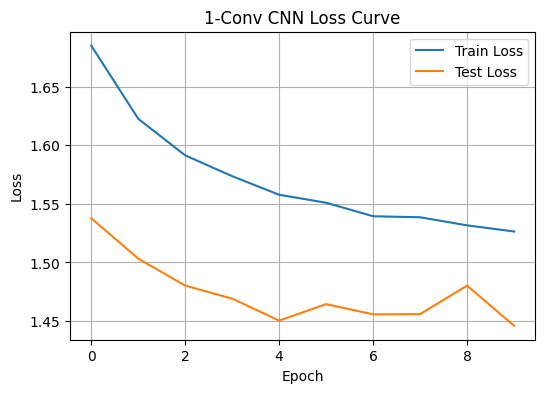

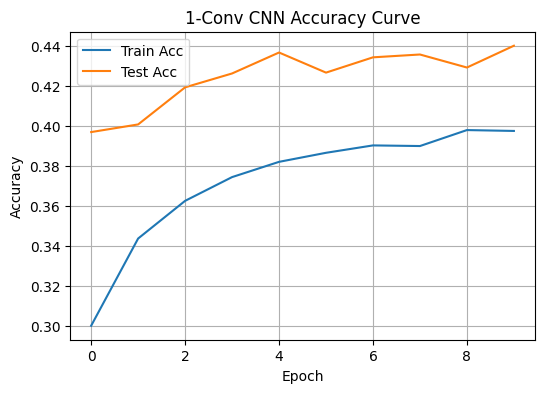

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(train_loss_history, label='Train Loss')
plt.plot(test_loss_history, label='Test Loss')
plt.title("1-Conv CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_acc_history, label='Train Acc')
plt.plot(test_acc_history, label='Test Acc')
plt.title("1-Conv CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#How to design second layer convolutional
class FER_CNN_2Conv(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)


        flattened_dim = 32 * 12 * 12
        self.fc = nn.Linear(flattened_dim, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [ ]:
#How to train the model and get the train loss and test loss
NUM_EPOCHS    = 50
LEARNING_RATE = 0.001

model = FER_CNN_2Conv(num_classes=NUM_CLASSES).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_function = nn.CrossEntropyLoss()

train_loss_history = []
test_loss_history  = []
train_acc_history  = []
test_acc_history   = []

best_val_acc = 0.0
best_state   = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_function, optimizer)
    val_loss,   val_acc   = evaluate(model, val_loader,   loss_function)
    test_loss,  test_acc  = evaluate(model, test_loader,  loss_function)

    train_loss_history.append(train_loss)
    test_loss_history.append(test_loss)
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = model.state_dict()

    print(f"Epoch [{epoch}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}   | Val Acc: {val_acc:.4f}   | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

model.load_state_dict(best_state)
final_test_loss, final_test_acc = evaluate(model, test_loader, loss_function)
print(f"\n[FINAL]  Test Loss: {final_test_loss:.4f} | Test Acc: {final_test_acc:.4f}")

Epoch [1/50] Train Loss: 1.6858 | Train Acc: 0.2984 | Val Loss: 1.6310   | Val Acc: 0.3416   | Test Loss: 1.5825 | Test Acc: 0.3713
Epoch [2/50] Train Loss: 1.5922 | Train Acc: 0.3576 | Val Loss: 1.5590   | Val Acc: 0.3812   | Test Loss: 1.4511 | Test Acc: 0.4279
Epoch [3/50] Train Loss: 1.5337 | Train Acc: 0.3902 | Val Loss: 1.5184   | Val Acc: 0.4006   | Test Loss: 1.4063 | Test Acc: 0.4575
Epoch [4/50] Train Loss: 1.4976 | Train Acc: 0.4087 | Val Loss: 1.4956   | Val Acc: 0.4059   | Test Loss: 1.3619 | Test Acc: 0.4670
Epoch [5/50] Train Loss: 1.4661 | Train Acc: 0.4230 | Val Loss: 1.4735   | Val Acc: 0.4268   | Test Loss: 1.3629 | Test Acc: 0.4684
Epoch [6/50] Train Loss: 1.4478 | Train Acc: 0.4315 | Val Loss: 1.4463   | Val Acc: 0.4264   | Test Loss: 1.3302 | Test Acc: 0.4824
Epoch [7/50] Train Loss: 1.4349 | Train Acc: 0.4370 | Val Loss: 1.4301   | Val Acc: 0.4346   | Test Loss: 1.3079 | Test Acc: 0.4957
Epoch [8/50] Train Loss: 1.4200 | Train Acc: 0.4424 | Val Loss: 1.4284   | V

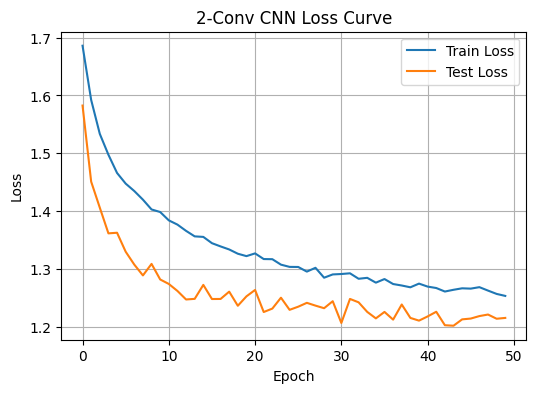

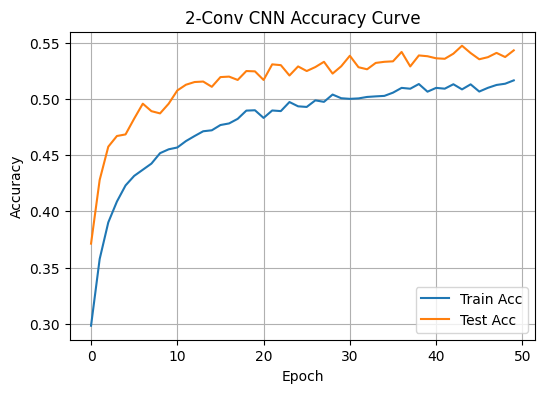

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(train_loss_history, label="Train Loss")
plt.plot(test_loss_history, label="Test Loss")
plt.title("2-Conv CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_acc_history, label="Train Acc")
plt.plot(test_acc_history, label="Test Acc")
plt.title("2-Conv CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#How to design third layer convolutional
class FER_VGG_Small(nn.Module):


    def __init__(self, num_classes=6, drop=0.5):
        super().__init__()

        self.conv1a = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1a   = nn.BatchNorm2d(32)
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1b   = nn.BatchNorm2d(32)

        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2a   = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2b   = nn.BatchNorm2d(64)

        self.conv3a = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3a   = nn.BatchNorm2d(128)
        self.conv3b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3b   = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.drop = nn.Dropout(drop)

        self.fc1 = nn.Linear(128 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1a(self.conv1a(x)))
        x = F.relu(self.bn1b(self.conv1b(x)))
        x = self.pool(x)

        x = F.relu(self.bn2a(self.conv2a(x)))
        x = F.relu(self.bn2b(self.conv2b(x)))
        x = self.pool(x)

        x = F.relu(self.bn3a(self.conv3a(x)))
        x = F.relu(self.bn3b(self.conv3b(x)))
        x = self.pool(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x


In [ ]:
#How to train the model and get the train loss and test loss
NUM_EPOCHS    = 70
LEARNING_RATE = 0.005

model = FER_VGG_Small(num_classes=NUM_CLASSES, drop=0.5).to(DEVICE)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)


optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE,
    momentum=0.9,
    nesterov=True,
    weight_decay=1e-4
)
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.75,
    patience=2,
    cooldown=1

)

conv3_train_loss_history = []
conv3_val_loss_history   = []
conv3_test_loss_history  = []

conv3_train_acc_history  = []
conv3_val_acc_history    = []
conv3_test_acc_history   = []

best_val_acc = 0.0
best_state   = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer)
    val_loss,   val_acc   = evaluate(model, val_loader,   loss_fn)
    test_loss,  test_acc  = evaluate(model, test_loader,  loss_fn)

    conv3_train_loss_history.append(train_loss)
    conv3_val_loss_history.append(val_loss)
    conv3_test_loss_history.append(test_loss)

    conv3_train_acc_history.append(train_acc)
    conv3_val_acc_history.append(val_acc)
    conv3_test_acc_history.append(test_acc)

    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = model.state_dict()

    print(
        f"Epoch [{epoch}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
    )

model.load_state_dict(best_state)

final_test_loss, final_test_acc = evaluate(model, test_loader, loss_fn)
print(f"\n[FINAL VGG-Small] Test Loss: {final_test_loss:.4f} | Test Acc: {final_test_acc:.4f}")



Epoch [1/70] Train Loss: 1.7098 | Train Acc: 0.2933 | Val Loss: 1.6129 | Val Acc: 0.3554 | Test Loss: 1.5580 | Test Acc: 0.3948
Epoch [2/70] Train Loss: 1.5884 | Train Acc: 0.3745 | Val Loss: 1.5224 | Val Acc: 0.4123 | Test Loss: 1.4482 | Test Acc: 0.4675
Epoch [3/70] Train Loss: 1.5259 | Train Acc: 0.4176 | Val Loss: 1.5119 | Val Acc: 0.4279 | Test Loss: 1.5061 | Test Acc: 0.4221
Epoch [4/70] Train Loss: 1.4825 | Train Acc: 0.4448 | Val Loss: 1.4233 | Val Acc: 0.4869 | Test Loss: 1.3806 | Test Acc: 0.4988
Epoch [5/70] Train Loss: 1.4491 | Train Acc: 0.4613 | Val Loss: 1.4156 | Val Acc: 0.4714 | Test Loss: 1.3497 | Test Acc: 0.5156
Epoch [6/70] Train Loss: 1.4269 | Train Acc: 0.4776 | Val Loss: 1.3909 | Val Acc: 0.4894 | Test Loss: 1.3349 | Test Acc: 0.5180
Epoch [7/70] Train Loss: 1.4036 | Train Acc: 0.4936 | Val Loss: 1.3791 | Val Acc: 0.4940 | Test Loss: 1.3294 | Test Acc: 0.5313
Epoch [8/70] Train Loss: 1.3856 | Train Acc: 0.5071 | Val Loss: 1.3525 | Val Acc: 0.5053 | Test Loss: 1.

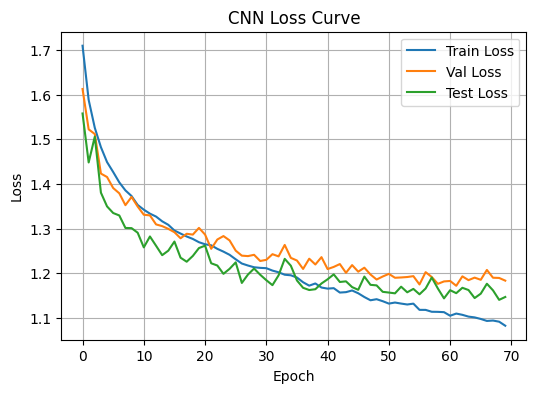

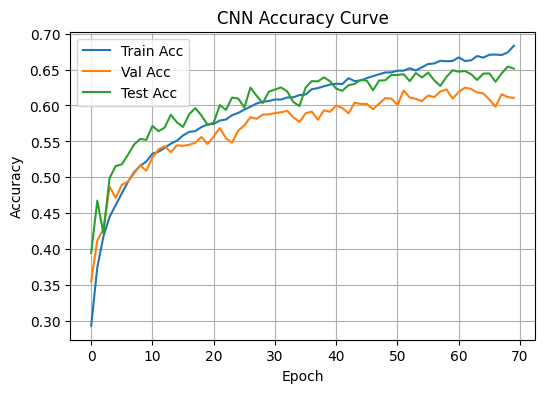

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(conv3_train_loss_history, label="Train Loss")
plt.plot(conv3_val_loss_history,   label="Val Loss")
plt.plot(conv3_test_loss_history,  label="Test Loss")
plt.title("CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(conv3_train_acc_history, label="Train Acc")
plt.plot(conv3_val_acc_history,   label="Val Acc")
plt.plot(conv3_test_acc_history,  label="Test Acc")
plt.title("CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


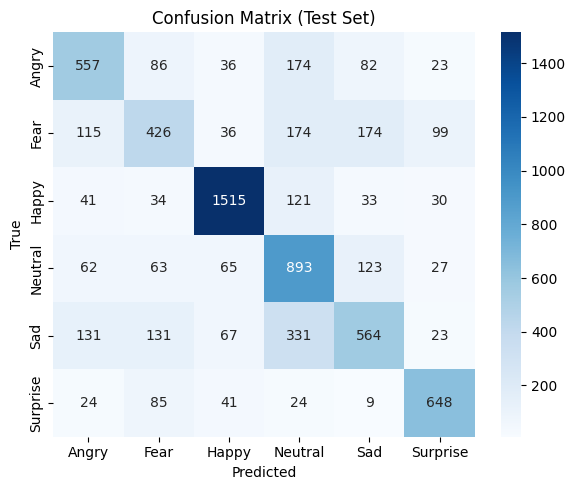

In [ ]:
#How to plot confusion matrix
class_names = ["Angry", "Fear", "Happy", "Neutral", "Sad", "Surprise"]

model.eval()
all_labels = []
all_preds  = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()



In [ ]:
per_class_acc = np.diag(cm) / cm.sum(axis=1)

print("Per-class accuracy on test set:")
for name, acc in zip(class_names, per_class_acc):
    print(f"{name:8s}: {acc:.3f}  ({acc*100:.1f}%)")


Per-class accuracy on test set:
Angry   : 0.581  (58.1%)
Fear    : 0.416  (41.6%)
Happy   : 0.854  (85.4%)
Neutral : 0.724  (72.4%)
Sad     : 0.452  (45.2%)
Surprise: 0.780  (78.0%)


# KNN：

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import zipfile
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [ ]:
model1_zip_path = "/content/archive.zip"
model1_extract_path = "./content/fer2013_data"

if not os.path.exists(model1_extract_path):
    print("Extracting zip file...")
    with zipfile.ZipFile(model1_zip_path, 'r') as model1_zip_ref:
        model1_zip_ref.extractall(model1_extract_path)

model1_train_dir = model1_extract_path + "/train"
model1_test_dir  = model1_extract_path + "/test"

print("Train dir:", model1_train_dir)
print("Test dir:", model1_test_dir)

Extracting zip file...
Train dir: ./content/fer2013_data/train
Test dir: ./content/fer2013_data/test


In [ ]:
#How to load image
def model1_load_images(model1_root):
    model1_X = []
    model1_y = []
    model1_class_names = sorted(os.listdir(model1_root))

    for model1_cls in model1_class_names:
        model1_cls_dir = os.path.join(model1_root, model1_cls)
        if not os.path.isdir(model1_cls_dir):
            continue

        for model1_fname in os.listdir(model1_cls_dir):
            model1_fpath = os.path.join(model1_cls_dir, model1_fname)

            model1_img = Image.open(model1_fpath).convert("L")
            model1_img = np.array(model1_img)

            model1_X.append(model1_img)
            model1_y.append(model1_cls)

    return np.array(model1_X), np.array(model1_y), model1_class_names

model1_X_train, model1_y_train, model1_classes_train = model1_load_images(model1_train_dir)
model1_X_test, model1_y_test, model1_classes_test = model1_load_images(model1_test_dir)

print("Train images:", model1_X_train.shape)
print("Test images:", model1_X_test.shape)

Train images: (28709, 48, 48)
Test images: (7178, 48, 48)


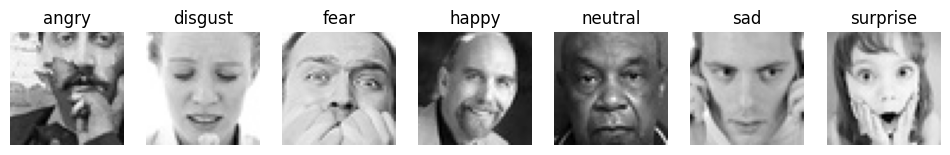

In [ ]:
plt.figure(figsize=(12, 4))

for model1_i, model1_cls in enumerate(model1_classes_train):
    model1_idx = np.where(model1_y_train == model1_cls)[0][0]
    plt.subplot(1, len(model1_classes_train), model1_i+1)
    plt.imshow(model1_X_train[model1_idx], cmap="gray")
    plt.title(model1_cls)
    plt.axis("off")

plt.show()

Training samples per emotion:
angry: 3995
disgust: 436
fear: 4097
happy: 7215
neutral: 4965
sad: 4830
surprise: 3171

Testing samples per emotion:
angry: 958
disgust: 111
fear: 1024
happy: 1774
neutral: 1233
sad: 1247
surprise: 831


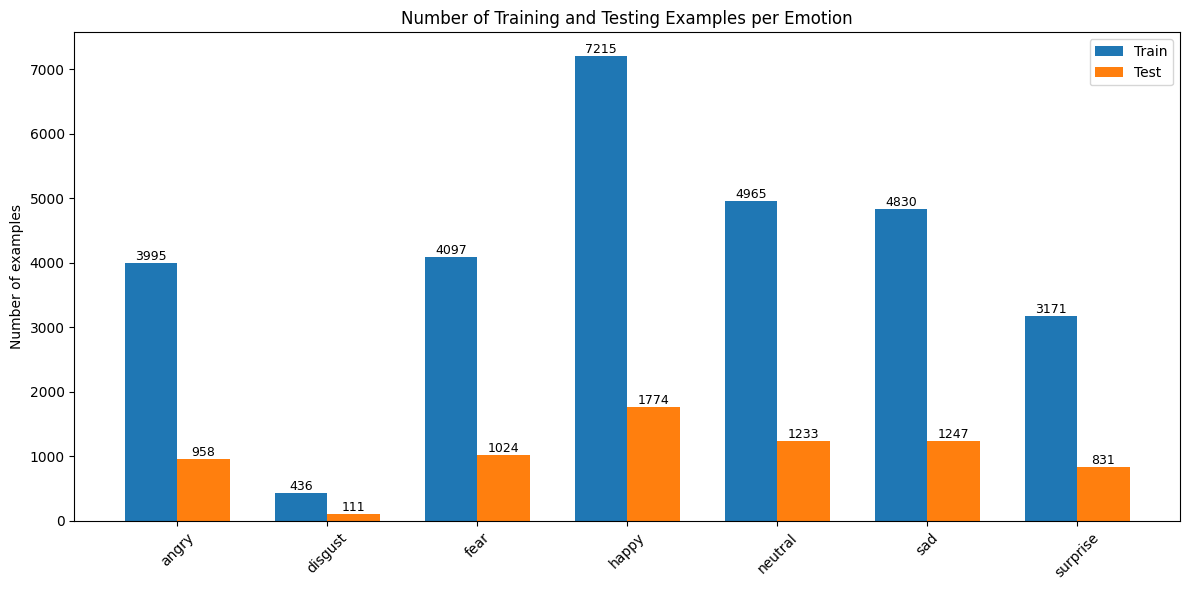

In [ ]:
#How to plot the data
from collections import Counter

model1_train_counts = Counter(model1_y_train)
model1_test_counts  = Counter(model1_y_test)

print("Training samples per emotion:")
for model1_cls in model1_classes_train:
    print(f"{model1_cls}: {model1_train_counts[model1_cls]}")

print("\nTesting samples per emotion:")
for model1_cls in model1_classes_test:
    print(f"{model1_cls}: {model1_test_counts[model1_cls]}")



plt.figure(figsize=(12, 6))

model1_labels = model1_classes_train
model1_train_values = [model1_train_counts[cls] for cls in model1_labels]
model1_test_values  = [model1_test_counts[cls]  for cls in model1_labels]

model1_x = np.arange(len(model1_labels))
model1_width = 0.35

model1_bars1 = plt.bar(model1_x - model1_width/2, model1_train_values, model1_width, label="Train")
model1_bars2 = plt.bar(model1_x + model1_width/2, model1_test_values,  model1_width, label="Test")

plt.ylabel("Number of examples")
plt.title("Number of Training and Testing Examples per Emotion")
plt.xticks(model1_x, model1_labels, rotation=45)
plt.legend()

for bar in model1_bars1:
    model1_h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, model1_h,
             str(model1_h), ha='center', va='bottom', fontsize=9)

for bar in model1_bars2:
    model1_h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, model1_h,
             str(model1_h), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
#How to drop the disgust group
model1_drop_class = "disgust"

model1_mask_train = (model1_y_train != model1_drop_class)
model1_X_train_drop = model1_X_train[model1_mask_train]
model1_y_train_drop = model1_y_train[model1_mask_train]

model1_mask_test = (model1_y_test != model1_drop_class)
model1_X_test_drop = model1_X_test[model1_mask_test]
model1_y_test_drop = model1_y_test[model1_mask_test]

print("===== Train class counts =====")
for model1_cls in sorted(np.unique(model1_y_train_drop)):
    print(f"{model1_cls}: {np.sum(model1_y_train_drop == model1_cls)}")

print("Total train samples:", len(model1_y_train_drop))

print("\n===== Test class counts =====")
for model1_cls in sorted(np.unique(model1_y_test_drop)):
    print(f"{model1_cls}: {np.sum(model1_y_test_drop == model1_cls)}")

print("Total test samples:", len(model1_y_test_drop))

===== Train class counts =====
angry: 3995
fear: 4097
happy: 7215
neutral: 4965
sad: 4830
surprise: 3171
Total train samples: 28273

===== Test class counts =====
angry: 958
fear: 1024
happy: 1774
neutral: 1233
sad: 1247
surprise: 831
Total test samples: 7067


In [ ]:
model1_X_train_flat = model1_X_train_drop.reshape(len(model1_X_train_drop), -1)
model1_X_test_flat  = model1_X_test_drop.reshape(len(model1_X_test_drop), -1)

print("Train shape:", model1_X_train_flat.shape)
print("Test shape:", model1_X_test_flat.shape)

# normalization
model1_scaler = StandardScaler()
model1_X_train_norm = model1_scaler.fit_transform(model1_X_train_flat)
model1_X_test_norm  = model1_scaler.transform(model1_X_test_flat)

print("Normalized train shape:", model1_X_train_norm.shape)
print("Normalized test shape:",  model1_X_test_norm.shape)

Train shape: (28273, 2304)
Test shape: (7067, 2304)
Normalized train shape: (28273, 2304)
Normalized test shape: (7067, 2304)


In [ ]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score


====== Running PCA dim = 2 ======
  Training KNN with K=3...
    K=3 → accuracy=0.2585
  Training KNN with K=5...
    K=5 → accuracy=0.2663
  Training KNN with K=7...
    K=7 → accuracy=0.2638
  Training KNN with K=9...
    K=9 → accuracy=0.2680
  Training KNN with K=11...
    K=11 → accuracy=0.2701
  Training KNN with K=13...
    K=13 → accuracy=0.2728
  Training KNN with K=15...
    K=15 → accuracy=0.2761
  Training KNN with K=17...
    K=17 → accuracy=0.2768
  Training KNN with K=19...
    K=19 → accuracy=0.2762
  Training KNN with K=21...
    K=21 → accuracy=0.2771
  Training KNN with K=23...
    K=23 → accuracy=0.2773
  Training KNN with K=25...
    K=25 → accuracy=0.2799
  Training KNN with K=27...
    K=27 → accuracy=0.2773
  Training KNN with K=29...
    K=29 → accuracy=0.2796
  Training KNN with K=31...
    K=31 → accuracy=0.2823
  Training KNN with K=33...
    K=33 → accuracy=0.2834

====== Running PCA dim = 5 ======
  Training KNN with K=3...
    K=3 → accuracy=0.3324
  Tra

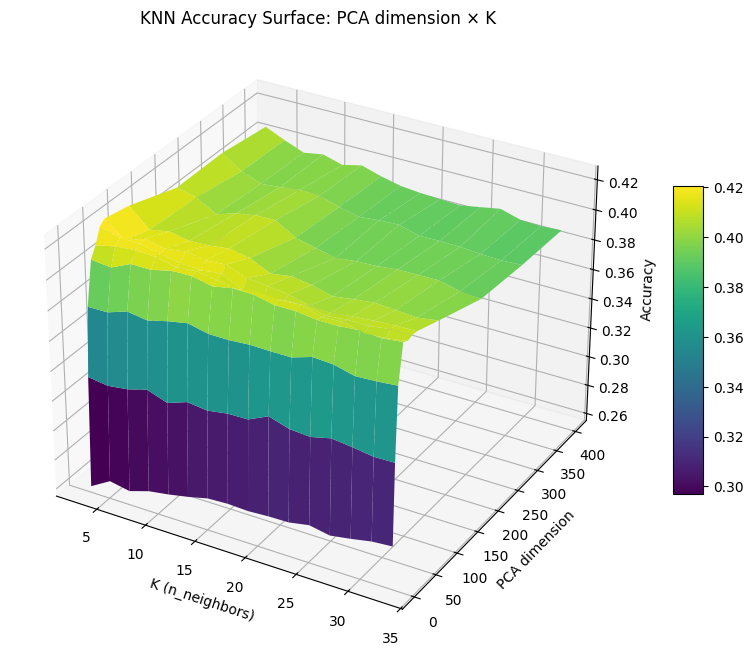

In [ ]:
#How to write a doule loop of PCA dimension and different k
model1_pca_dims = [2, 5, 10, 20, 30, 40, 50, 100, 200, 300, 400]
model1_K_list = list(range(3, 35, 2))

model1_acc_matrix = np.zeros((len(model1_pca_dims), len(model1_K_list)))

for model1_i, model1_pca_dim in enumerate(model1_pca_dims):
    print(f"\n====== Running PCA dim = {model1_pca_dim} ======")

    model1_pca = PCA(n_components=model1_pca_dim)
    model1_X_train_pca = model1_pca.fit_transform(model1_X_train_norm)
    model1_X_test_pca  = model1_pca.transform(model1_X_test_norm)

    for model1_j, model1_K in enumerate(model1_K_list):
        print(f"  Training KNN with K={model1_K}...")

        model1_knn = KNeighborsClassifier(n_neighbors=model1_K, n_jobs=-1, weights='distance')
        model1_knn.fit(model1_X_train_pca, model1_y_train_drop)

        model1_y_pred = model1_knn.predict(model1_X_test_pca)
        model1_acc = accuracy_score(model1_y_test_drop, model1_y_pred)

        model1_acc_matrix[model1_i, model1_j] = model1_acc

        print(f"    K={model1_K} → accuracy={model1_acc:.4f}")


model1_best_idx = np.unravel_index(np.argmax(model1_acc_matrix), model1_acc_matrix.shape)
model1_best_pca = model1_pca_dims[model1_best_idx[0]]
model1_best_K = model1_K_list[model1_best_idx[1]]
model1_best_acc = model1_acc_matrix[model1_best_idx]

print("\n==========================")
print(f"Best dimension: {model1_best_pca}")
print(f"Best K: {model1_best_K}")
print(f"Best Accuracy: {model1_best_acc:.4f}")
print("==========================")


model1_X_mesh, model1_Y_mesh = np.meshgrid(model1_K_list, model1_pca_dims)

fig = plt.figure(figsize=(12, 8))
model1_ax = fig.add_subplot(111, projection='3d')

model1_surf = model1_ax.plot_surface(model1_X_mesh, model1_Y_mesh, model1_acc_matrix,
                                     cmap='viridis', edgecolor='none')

model1_ax.set_xlabel("K (n_neighbors)")
model1_ax.set_ylabel("PCA dimension")
model1_ax.set_zlabel("Accuracy")
model1_ax.set_title("KNN Accuracy Surface: PCA dimension × K")

fig.colorbar(model1_surf, shrink=0.5, aspect=10)
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

PCA done. Shape: (28273, 50)
Overall accuracy: 0.4229517475590774

===== Classification Report =====
              precision    recall  f1-score   support

       angry       0.37      0.34      0.35       958
        fear       0.42      0.40      0.41      1024
       happy       0.47      0.49      0.48      1774
     neutral       0.33      0.38      0.36      1233
         sad       0.37      0.32      0.34      1247
    surprise       0.59      0.63      0.61       831

    accuracy                           0.42      7067
   macro avg       0.43      0.43      0.42      7067
weighted avg       0.42      0.42      0.42      7067

===== Per-class Accuracy =====
angry: 0.3361
fear: 0.4014
happy: 0.4865
neutral: 0.3836
sad: 0.3176
surprise: 0.6306


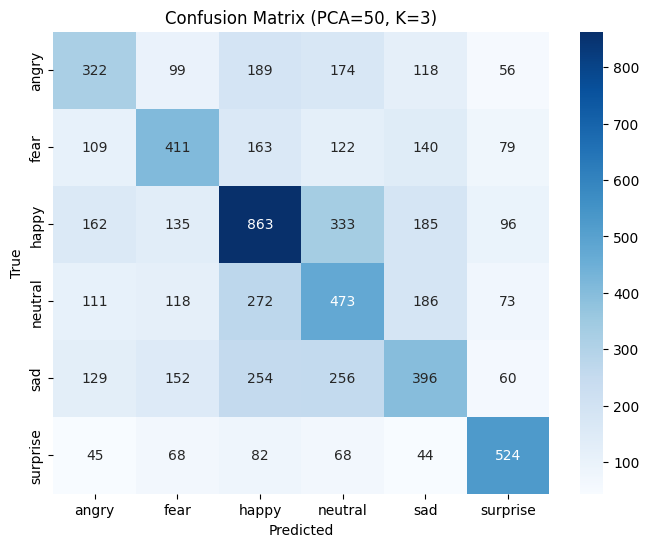

In [ ]:
#How to write confusion matrix
model1_best_pca = 50
model1_best_K = 3

model1_pca = PCA(n_components=model1_best_pca)
model1_X_train_pca = model1_pca.fit_transform(model1_X_train_norm)
model1_X_test_pca  = model1_pca.transform(model1_X_test_norm)

print("PCA done. Shape:", model1_X_train_pca.shape)

model1_knn = KNeighborsClassifier(
    n_neighbors=model1_best_K,
    weights='distance',
    n_jobs=-1
)

model1_knn.fit(model1_X_train_pca, model1_y_train_drop)
model1_y_pred = model1_knn.predict(model1_X_test_pca)

model1_overall_acc = accuracy_score(model1_y_test_drop, model1_y_pred)
print("Overall accuracy:", model1_overall_acc)

print("\n===== Classification Report =====")
print(classification_report(model1_y_test_drop, model1_y_pred))

model1_classes = model1_knn.classes_
model1_cm = confusion_matrix(model1_y_test_drop, model1_y_pred)

print("===== Per-class Accuracy =====")
model1_per_class_acc = model1_cm.diagonal() / model1_cm.sum(axis=1)

for model1_cls, model1_acc in zip(model1_classes, model1_per_class_acc):
    print(f"{model1_cls}: {model1_acc:.4f}")

plt.figure(figsize=(8,6))
sns.heatmap(model1_cm, annot=True, fmt="d",
            xticklabels=model1_classes,
            yticklabels=model1_classes,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (PCA={model1_best_pca}, K={model1_best_K})")
plt.show()


# extra credit


In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [ ]:
extra_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", extra_DEVICE)

extra_DATA_ROOT = "/content"
extra_BATCH_SIZE = 128
extra_IMAGE_SIZE = 224

extra_IMAGENET_MEAN = [0.485, 0.456, 0.406]
extra_IMAGENET_STD  = [0.229, 0.224, 0.225]


Using: cuda


In [ ]:
# prompt: write me a function to drop the disgust class.
def drop_class(extra_dataset, extra_class_name="disgust"):
    if extra_class_name not in extra_dataset.class_to_idx:
        print(f"{extra_class_name} not found, nothing removed.")
        return extra_dataset

    extra_drop_idx = extra_dataset.class_to_idx[extra_class_name]
    extra_new_samples = []

    for extra_path, extra_label in extra_dataset.samples:
        if extra_label == extra_drop_idx:
            continue
        extra_new_label = extra_label - 1 if extra_label > extra_drop_idx else extra_label
        extra_new_samples.append((extra_path, extra_new_label))

    extra_dataset.samples = extra_new_samples
    extra_dataset.imgs = extra_new_samples
    extra_dataset.classes = [c for c in extra_dataset.classes if c != extra_class_name]
    extra_dataset.class_to_idx = {c: i for i, c in enumerate(extra_dataset.classes)}

    print(f"Removed '{extra_class_name}'. New classes:", extra_dataset.classes)
    return extra_dataset


In [ ]:
# prompt: write me a function to drop the disgust class.
extra_train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomResizedCrop(extra_IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=extra_IMAGENET_MEAN, std=extra_IMAGENET_STD),
    transforms.RandomErasing(p=0.5)
])

extra_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((extra_IMAGE_SIZE, extra_IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=extra_IMAGENET_MEAN, std=extra_IMAGENET_STD),
])

extra_train_dataset = datasets.ImageFolder(os.path.join(extra_DATA_ROOT, "train"), transform=extra_train_transform)
extra_test_dataset  = datasets.ImageFolder(os.path.join(extra_DATA_ROOT, "test"),  transform=extra_test_transform)

extra_train_dataset = drop_class(extra_train_dataset, "disgust")
extra_test_dataset  = drop_class(extra_test_dataset,  "disgust")

extra_NUM_CLASSES = len(extra_train_dataset.classes)
print("NUM_CLASSES =", extra_NUM_CLASSES)

extra_train_loader = DataLoader(extra_train_dataset, batch_size=extra_BATCH_SIZE, shuffle=True, num_workers=2)
extra_test_loader  = DataLoader(extra_test_dataset,  batch_size=extra_BATCH_SIZE, shuffle=False, num_workers=2)


Removed 'disgust'. New classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Removed 'disgust'. New classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
NUM_CLASSES = 6


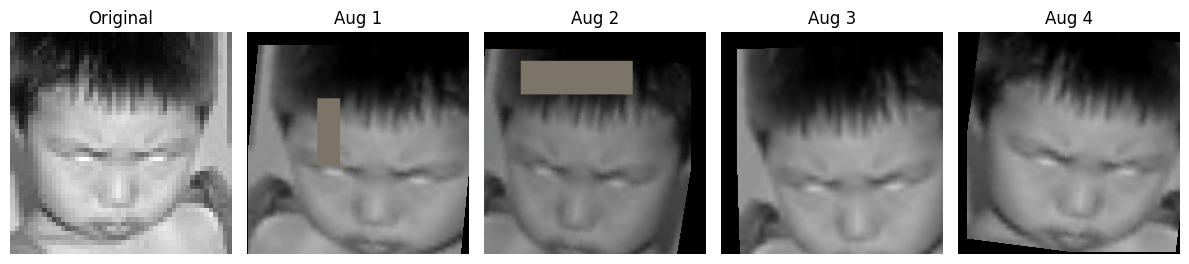

In [ ]:
# prompt "how to print out the result of the augmented images"
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

extra_sample_img_path, extra_sample_label = extra_train_dataset.samples[0]

extra_orig_img = Image.open(extra_sample_img_path)

plt.figure(figsize=(12, 4))
plt.subplot(1, 5, 1)
plt.imshow(extra_orig_img, cmap='gray')
plt.title("Original")
plt.axis("off")

def extra_denormalize(extra_img_tensor):
    extra_img = extra_img_tensor.permute(1, 2, 0).numpy()
    extra_img = extra_img * np.array(extra_IMAGENET_STD) + np.array(extra_IMAGENET_MEAN)
    return np.clip(extra_img, 0, 1)

for extra_i in range(4):
    extra_img = Image.open(extra_sample_img_path)
    extra_aug_tensor = extra_train_transform(extra_img)
    extra_aug_img = extra_denormalize(extra_aug_tensor)

    plt.subplot(1, 5, extra_i + 2)
    plt.imshow(extra_aug_img)
    plt.title(f"Aug {extra_i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
#How to train the model
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        total_correct += preds.eq(labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            total_correct += preds.eq(labels).sum().item()
            total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples
import copy

Using device: cuda


In [ ]:
# prompt "help me implement the ResNest18 based on the hyperparameters"
import torch.nn as nn
from torchvision import models
import torch
import torch.nn as nn
import copy


class FER_ResNet18(nn.Module):
    def __init__(self, extra_num_classes):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        extra_in_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(extra_in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, extra_num_classes)
        )

    def forward(self, extra_x):
        return self.backbone(extra_x)


extra_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
extra_model = FER_ResNet18(extra_num_classes=extra_NUM_CLASSES).to(extra_DEVICE)

extra_optimizer = torch.optim.SGD(
    extra_model.parameters(),
    lr=0.01,
    momentum=0.9,
    nesterov=True,
    weight_decay=1e-4
)

extra_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    extra_optimizer,
    mode="min",
    factor=0.5,
    patience=3,
)

extra_criterion = nn.CrossEntropyLoss()

extra_num_epochs = 25

extra_best_val_acc = 0
extra_best_state = copy.deepcopy(extra_model.state_dict())

extra_train_losses, extra_train_accs = [], []
extra_val_losses, extra_val_accs = [], []

for extra_epoch in range(1, extra_num_epochs + 1):
    extra_train_loss, extra_train_acc = train_one_epoch(
        extra_model, extra_train_loader, extra_criterion, extra_optimizer, extra_DEVICE
    )

    extra_val_loss, extra_val_acc = evaluate(
        extra_model, extra_test_loader, extra_criterion, extra_DEVICE
    )

    extra_scheduler.step(extra_val_loss)

    extra_train_losses.append(extra_train_loss)
    extra_train_accs.append(extra_train_acc)
    extra_val_losses.append(extra_val_loss)
    extra_val_accs.append(extra_val_acc)

    if extra_val_acc > extra_best_val_acc:
        extra_best_val_acc = extra_val_acc
        extra_best_state = copy.deepcopy(extra_model.state_dict())

    print(f"Epoch [{extra_epoch}/{extra_num_epochs}] "
          f"Train Loss: {extra_train_loss:.4f} | Train Acc: {extra_train_acc:.4f} | "
          f"Val Loss: {extra_val_loss:.4f} | Val Acc: {extra_val_acc:.4f}")

extra_model.load_state_dict(extra_best_state)

extra_final_loss, extra_final_acc = evaluate(
    extra_model, extra_test_loader, extra_criterion, extra_DEVICE
)

print("\n===== FINAL TEST RESULT =====")
print(f"Test Loss: {extra_final_loss:.4f} | Test Acc: {extra_final_acc:.4f}")


Epoch [1/25] Train Loss: 1.4291 | Train Acc: 0.4241 | Val Loss: 1.1276 | Val Acc: 0.5608
Epoch [2/25] Train Loss: 1.1382 | Train Acc: 0.5584 | Val Loss: 1.0047 | Val Acc: 0.6078
Epoch [3/25] Train Loss: 1.0623 | Train Acc: 0.5920 | Val Loss: 0.9752 | Val Acc: 0.6307
Epoch [4/25] Train Loss: 1.0141 | Train Acc: 0.6114 | Val Loss: 0.9474 | Val Acc: 0.6370
Epoch [5/25] Train Loss: 0.9786 | Train Acc: 0.6282 | Val Loss: 0.9329 | Val Acc: 0.6424
Epoch [6/25] Train Loss: 0.9474 | Train Acc: 0.6406 | Val Loss: 0.9651 | Val Acc: 0.6462
Epoch [7/25] Train Loss: 0.9245 | Train Acc: 0.6477 | Val Loss: 0.9797 | Val Acc: 0.6423
Epoch [8/25] Train Loss: 0.9004 | Train Acc: 0.6556 | Val Loss: 0.8745 | Val Acc: 0.6675
Epoch [9/25] Train Loss: 0.8889 | Train Acc: 0.6621 | Val Loss: 0.9024 | Val Acc: 0.6702
Epoch [10/25] Train Loss: 0.8661 | Train Acc: 0.6742 | Val Loss: 0.8923 | Val Acc: 0.6692
Epoch [11/25] Train Loss: 0.8496 | Train Acc: 0.6785 | Val Loss: 0.8655 | Val Acc: 0.6709
Epoch [12/25] Train

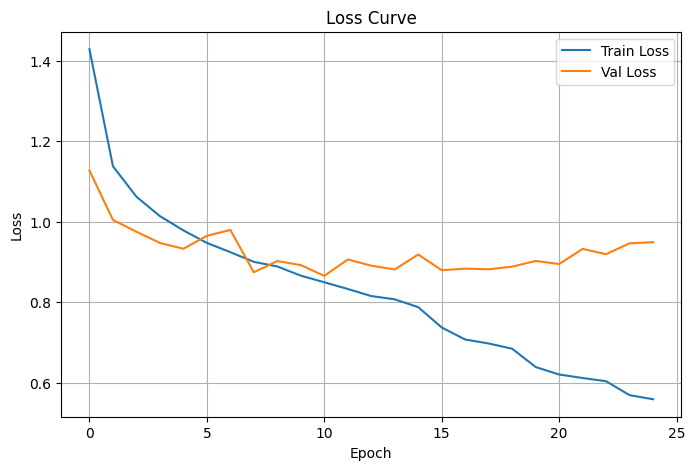

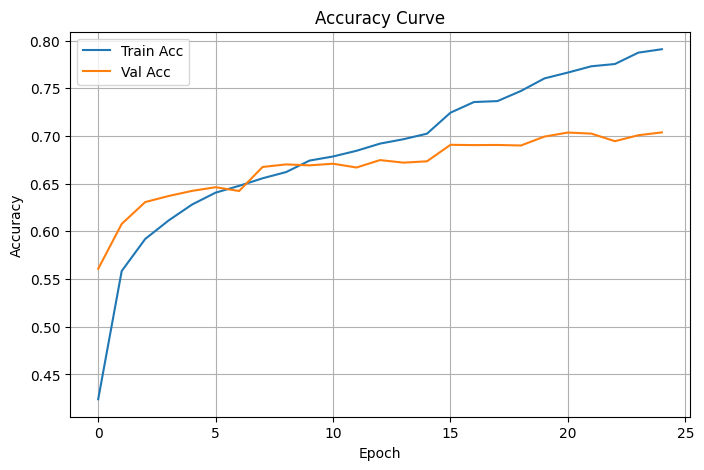

In [ ]:
# prompt "print out the result"
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(extra_train_losses, label="Train Loss")
plt.plot(extra_val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(extra_train_accs, label="Train Acc")
plt.plot(extra_val_accs, label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Confusion Matrix:
[[ 601  112   30   93  100   22]
 [ 104  550   22   94  173   81]
 [  27   26 1591   68   24   38]
 [  62   62   67  890  131   21]
 [ 117  181   50  239  649   11]
 [  24   62   28   14   11  692]]


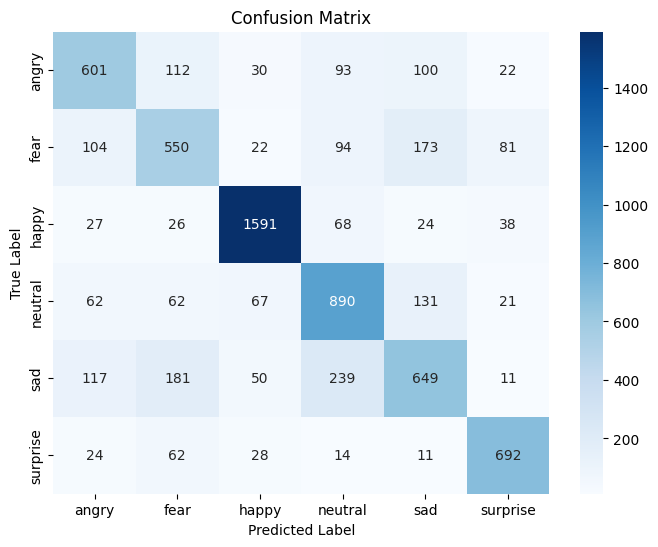

In [ ]:
# prompt "print out confusion matrix"
extra_all_preds = []
extra_all_labels = []

extra_model.eval()
with torch.no_grad():
    for extra_images, extra_labels in extra_test_loader:
        extra_images = extra_images.to(extra_DEVICE)
        extra_labels = extra_labels.to(extra_DEVICE)

        extra_outputs = extra_model(extra_images)
        _, extra_preds = extra_outputs.max(1)

        extra_all_preds.extend(extra_preds.cpu().numpy())
        extra_all_labels.extend(extra_labels.cpu().numpy())

extra_cm = confusion_matrix(extra_all_labels, extra_all_preds)
print("Confusion Matrix:")
print(extra_cm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    extra_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=extra_train_dataset.classes,
    yticklabels=extra_train_dataset.classes
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report
# prompt "print out the accuracy for each class"
print("\n===== Classification Report =====\n")
print(classification_report(
    extra_all_labels,
    extra_all_preds,
    target_names=extra_train_dataset.classes,
    digits=4
))

extra_cm = confusion_matrix(extra_all_labels, extra_all_preds)
extra_class_accuracy = extra_cm.diagonal() / extra_cm.sum(axis=1)

print("\n===== Per-Class Accuracy =====")
for extra_cls, extra_acc in zip(extra_train_dataset.classes, extra_class_accuracy):
    print(f"{extra_cls}: {extra_acc:.4f}")



===== Classification Report =====

              precision    recall  f1-score   support

       angry     0.6428    0.6273    0.6350       958
        fear     0.5539    0.5371    0.5454      1024
       happy     0.8898    0.8968    0.8933      1774
     neutral     0.6366    0.7218    0.6765      1233
         sad     0.5965    0.5204    0.5559      1247
    surprise     0.8000    0.8327    0.8160       831

    accuracy                         0.7037      7067
   macro avg     0.6866    0.6894    0.6870      7067
weighted avg     0.7012    0.7037    0.7014      7067


===== Per-Class Accuracy =====
angry: 0.6273
fear: 0.5371
happy: 0.8968
neutral: 0.7218
sad: 0.5204
surprise: 0.8327
